In [52]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

ANBIMA_FILENAME = "../data/raw/raio_x_investidor.xlsx"
df = pd.read_excel(ANBIMA_FILENAME, sheet_name=None)

In [53]:
# --------------------------------------------------------------
# Selecao criteriosa: apenas variaveis ordinais/binarias com semantica
# causal de risco, capacidade financeira, horizonte de tempo e disciplina.
# EXCLUIDOS: genero, cor, trans, orientsex, religiao1, escolac/escola,
# geografia/classe (sem relacao causal direta com risco financeiro).
# --------------------------------------------------------------
colunas = [
    'nquest',
    'idade', 'rendaf',
    'p1', 'p25',
    'p72', 'p74',
    'p65',
    'p66', 'p68', 'p73',
    'p27',
    'p64a', 'p64b', 'p64c', 'p64d',
    'p64e', 'p64f', 'p64g', 'p64h',
    'p64i', 'p64j', 'p64k', 'p64l',
]

df_modelo = df['VALUE'][colunas].copy()

df_modelo['p66'] = df_modelo['p66'].mask(df_modelo['p66'].isin([97, 99]), np.nan)

# Reordenar p66 para escala monotonica de risco:
# 1=todos os dias ... 6=raramente, 7=nao usou em 2025, 8=nunca usou
# -> inverter para que "nunca usou" = menor risco (0) e "todos os dias" = maior risco
mapa_p66 = {1: 7, 2: 6, 3: 5, 4: 4, 5: 3, 6: 2, 7: 1, 8: 0}
df_modelo['p66'] = df_modelo['p66'].map(mapa_p66)

df_modelo['p68'] = df_modelo['p68'].replace([97, 99], np.nan)
df_modelo['p68_percebe_como_investimento'] = (df_modelo['p68'] == 1).astype(float)
df_modelo.loc[df_modelo['p68'].isna(), 'p68_percebe_como_investimento'] = np.nan
df_modelo.drop(columns='p68', inplace=True)

# Codigos de nao-resposta/recusa padrao para as demais colunas
CODIGOS_NAO_RESPOSTA = [96, 97, 98, 99]
colunas_restantes = [c for c in df_modelo.columns if c not in ['nquest', 'p66', 'p68_percebe_como_investimento']]
for col in colunas_restantes:
    df_modelo[col] = df_modelo[col].mask(df_modelo[col].isin(CODIGOS_NAO_RESPOSTA), np.nan)

print("=== NULOS POR COLUNA (apos correcoes de p66 e p68) ===")
print(df_modelo.isnull().sum().sort_values(ascending=False))

=== NULOS POR COLUNA (apos correcoes de p66 e p68) ===
rendaf                           218
p72                               59
p64i                              52
p66                               51
p64e                              39
p64g                              28
p64a                              27
p64k                              24
p64j                              24
p64c                              23
p64b                              21
p64d                              20
p64f                              19
p64h                              16
p64l                              11
p68_percebe_como_investimento      6
p27                                1
p74                                0
p65                                0
p1                                 0
nquest                             0
idade                              0
p25                                0
p73                                0
dtype: int64


In [54]:
ids_investidores = df_modelo['nquest'].copy()
features = df_modelo.drop(columns='nquest').copy().dropna()

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

df_features_scaled = pd.DataFrame(
    features_scaled,
    columns=features.columns,
    index=features.index
)

print(df_features_scaled.head(3))

      idade    rendaf        p1       p25       p72       p74       p65  \
0  0.678894 -0.950188 -1.700356  0.185818  0.623634  0.534582  0.157004   
1  0.678894  1.611632  0.588112 -1.039583  0.623634  0.101187 -1.197591   
3 -0.056801 -0.629961 -1.700356  0.185818  0.623634 -0.765602 -1.197591   

        p66       p73       p27  ...      p64d      p64e      p64f      p64g  \
0 -0.573769 -0.124782 -0.407224  ... -1.157761 -1.114282 -0.830481 -0.723271   
1  0.066505 -0.124782 -0.412817  ... -0.616323 -1.114282  1.493575 -0.091476   
3  0.706780 -0.109789 -0.421208  ...  1.007991 -1.114282  0.912561 -0.091476   

       p64h      p64i      p64j      p64k      p64l  \
0 -0.679419 -1.027009  0.608328 -1.319940  0.709250   
1 -0.072683 -0.428899 -1.669108  0.406767  0.709250   
3  1.140790  0.767322 -2.428253  0.982336 -1.862526   

   p68_percebe_como_investimento  
0                      -0.106879  
1                      -0.106879  
3                      -0.106879  

[3 rows x 23 col

=== RESULTADOS DO PCA (variaveis refinadas) ===
Variancia Explicada por Componente:
[0.1909 0.0857 0.0682 0.0546 0.048  0.0437 0.0407 0.0399 0.0385 0.0377
 0.0338 0.0321 0.0307 0.0305 0.0293 0.0287 0.028  0.0263 0.0254 0.0246
 0.0227 0.0211 0.0189]

Variancia Acumulada:
[0.1909 0.2766 0.3448 0.3994 0.4475 0.4911 0.5318 0.5718 0.6102 0.648
 0.6818 0.7138 0.7445 0.775  0.8043 0.833  0.861  0.8873 0.9127 0.9373
 0.96   0.9811 1.    ]

Numero de componentes para 80% da variancia: 15


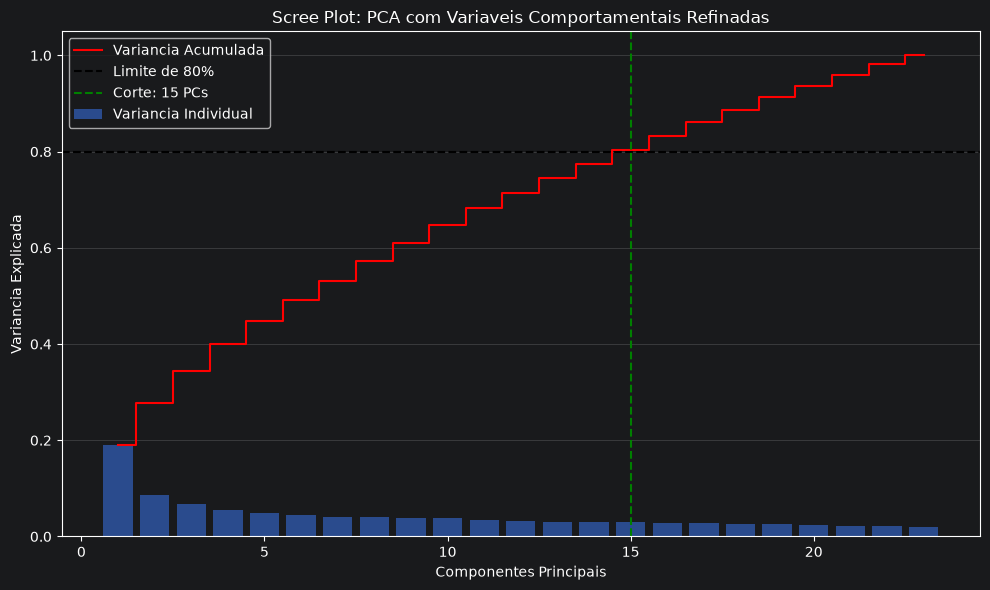

In [55]:

pca = PCA()
pca.fit(df_features_scaled)

variancia_explicada = pca.explained_variance_ratio_
variancia_acumulada = np.cumsum(variancia_explicada)

n_componentes_80 = np.argmax(variancia_acumulada >= 0.80) + 1
print("=== RESULTADOS DO PCA (variaveis refinadas) ===")
print("Variancia Explicada por Componente:")
print(np.round(variancia_explicada, 4))
print("\nVariancia Acumulada:")
print(np.round(variancia_acumulada, 4))
print(f"\nNumero de componentes para 80% da variancia: {n_componentes_80}")

plt.figure(figsize=(10, 6))
plt.bar(range(1, len(variancia_explicada) + 1), variancia_explicada, alpha=0.6, label='Variancia Individual')
plt.step(range(1, len(variancia_acumulada) + 1), variancia_acumulada, where='mid', color='r', label='Variancia Acumulada')
plt.axhline(y=0.80, color='k', linestyle='--', label='Limite de 80%')
plt.axvline(x=n_componentes_80, color='g', linestyle='--', label=f'Corte: {n_componentes_80} PCs')
plt.ylabel('Variancia Explicada')
plt.xlabel('Componentes Principais')
plt.title('Scree Plot: PCA com Variaveis Comportamentais Refinadas')
plt.legend(loc='best')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [56]:
pca_final = PCA(n_components=n_componentes_80)
X_pca = pca_final.fit_transform(df_features_scaled)
colunas_pca = [f'PC{i+1}' for i in range(X_pca.shape[1])]

df_pca = pd.DataFrame(X_pca, columns=colunas_pca)
df_pca = pd.concat([ids_investidores.reset_index(drop=True), df_pca], axis=1)
df_pca.to_csv('../data/processed/anbima_pca.csv', index=False)

# Loadings completos, para inspecao manual de TODOS os componentes retidos
df_loadings = pd.DataFrame(
    pca_final.components_.T,
    index=features.columns,
    columns=colunas_pca
)
df_loadings.to_csv('../data/processed/pca_loadings.csv')

print(f"=== LOADINGS COMPLETOS ({n_componentes_80} PCs) ===")
print(df_loadings.round(3))

for pc in df_loadings.columns:
    top5 = df_loadings[pc].abs().sort_values(ascending=False).head(5)
    print(f"\nTop 5 variaveis que definem {pc}:")
    print(top5)


=== LOADINGS COMPLETOS (15 PCs, variaveis refinadas) ===
                                 PC1    PC2    PC3    PC4    PC5    PC6  \
idade                          0.034  0.413  0.192  0.191  0.282 -0.115   
rendaf                         0.126  0.218  0.036  0.096  0.162  0.108   
p1                             0.173  0.290 -0.213  0.012 -0.202 -0.033   
p25                            0.173  0.299 -0.263  0.078 -0.112  0.085   
p72                           -0.181  0.177  0.107  0.149  0.024  0.037   
p74                           -0.226 -0.221  0.277  0.002  0.214 -0.009   
p65                           -0.282  0.002  0.150  0.052  0.130  0.067   
p66                            0.018 -0.342 -0.186  0.486 -0.042 -0.039   
p73                            0.011 -0.194 -0.163  0.465  0.034  0.149   
p27                            0.010  0.055 -0.098  0.054  0.072  0.924   
p64a                           0.357  0.075  0.012 -0.016 -0.035 -0.033   
p64b                           0.172 -0.263